In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
import warnings
warnings.filterwarnings('ignore')

In [27]:
df = pd.read_csv('europe-motorbikes-zenrows.csv')

In [28]:
print("Первые 5 строк данных:")
print(df.head())

Первые 5 строк данных:
   price  mileage  power              make_model     date      fuel    gear  \
0  23990      150  218.0                   Honda  03/2020  Gasoline  Manual   
1   7500     2871   90.0            BMW F 800 GT  09/2018  Gasoline  Manual   
2    800     1700    3.0  Nova Motors Retro Star  10/2019  Gasoline     NaN   
3  14990    24345    NaN            Aprilia RSV4  03/2016  Gasoline     NaN   
4   6200    25000  128.0    Kawasaki Ninja ZX-6R  08/2009  Gasoline     NaN   

      offer_type                   version  \
0  Demonstration  CBR1000RR-R Fireblade SP   
1           Used                       NaN   
2           Used                       NaN   
3           Used                        RF   
4           Used                       NaN   

                                                link  
0  /offers/honda-others-cbr1000rr-r-fireblade-sp-...  
1  /offers/bmw-f-800-gt-gasoline-white-f65273c6-6...  
2  /offers/nova-motors-retro-star-gasoline-red-f8...  
3  /o

In [29]:
print("\nИнформация о данных:")
print(df.info())


Информация о данных:
<class 'pandas.DataFrame'>
RangeIndex: 34917 entries, 0 to 34916
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   price       34917 non-null  int64  
 1   mileage     34917 non-null  int64  
 2   power       28598 non-null  float64
 3   make_model  34917 non-null  str    
 4   date        34917 non-null  str    
 5   fuel        31727 non-null  str    
 6   gear        12847 non-null  str    
 7   offer_type  34917 non-null  str    
 8   version     17413 non-null  str    
 9   link        34917 non-null  str    
dtypes: float64(1), int64(2), str(7)
memory usage: 2.7 MB
None


In [30]:
print("\nСтатистика по числовым столбцам:")
print(df.describe())


Статистика по числовым столбцам:
              price       mileage          power
count  3.491700e+04  3.491700e+04   28598.000000
mean   4.568532e+04  2.183175e+04     206.157598
std    4.850120e+06  2.059421e+05    9371.426466
min    1.000000e+00  0.000000e+00       1.000000
25%    6.999000e+03  2.932000e+03      50.000000
50%    9.920000e+03  1.100000e+04      90.000000
75%    1.259000e+04  2.500000e+04     125.000000
max    8.888889e+08  9.999999e+06  913595.000000


In [ ]:
def prepare_data_fixed(df):
    """Улучшенная версия подготовки данных."""
    data = df.copy()
    
    current_year = 2024
    def extract_year(date_str):
        if pd.isna(date_str) or date_str == '- (First Registration)':
            return np.nan
        try:
            return int(str(date_str).split('/')[-1])
        except:
            return np.nan
    
    data['reg_year'] = data['date'].apply(extract_year)
    data['age'] = current_year - data['reg_year']
    
    data = data[data['price'] > 1000]
    data = data[data['price'] < 100_000_000]
    
    data['price_log'] = np.log1p(data['price'])
    
    data['power'] = pd.to_numeric(data['power'], errors='coerce')
    data = data[(data['power'] >= 5) & (data['power'] <= 500)]
    
    model_avg_price = data.groupby('make_model')['price'].transform('mean')
    data['price_vs_model_avg'] = data['price'] / model_avg_price
    
    essential_cols = ['price', 'mileage', 'power', 'make_model']
    data = data.dropna(subset=essential_cols, how='any')
    
    categorical = ['fuel', 'gear', 'offer_type']
    data = pd.get_dummies(data, columns=categorical, dummy_na=False)
    
    print(f"Данные после очистки: {data.shape}")
    print(f"Диапазон цен: {data['price'].min():,.0f} - {data['price'].max():,.0f}")
    print(f"Средняя цена: {data['price'].mean():,.0f}")
    
    return data

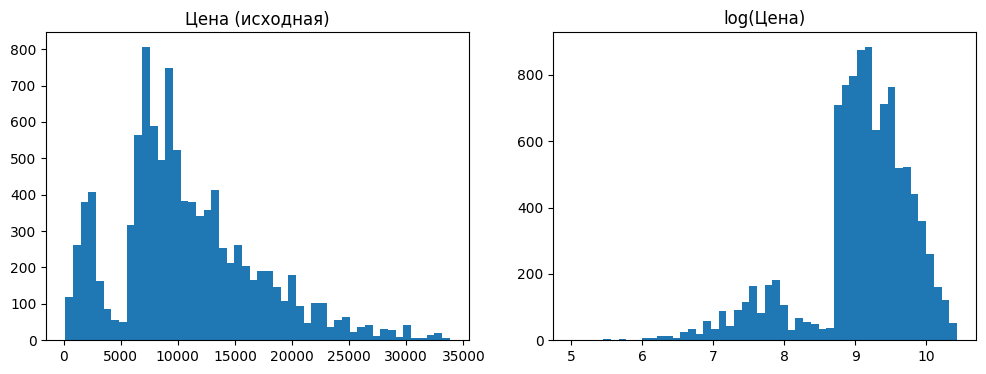

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(cleaned_df['price'], bins=50)
axes[0].set_title('Цена (исходная)')
axes[1].hist(np.log1p(cleaned_df['price']), bins=50)
axes[1].set_title('log(Цена)')
plt.show()

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'BMW'),
  Text(1, 0, 'Harley-Davidson'),
  Text(2, 0, 'Honda'),
  Text(3, 0, 'Yamaha'),
  Text(4, 0, 'Ducati'),
  Text(5, 0, 'Kawasaki'),
  Text(6, 0, 'KTM'),
  Text(7, 0, 'Suzuki'),
  Text(8, 0, 'Triumph'),
  Text(9, 0, 'Piaggio')])

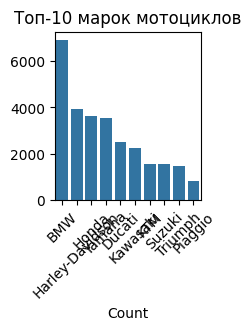

In [42]:
plt.subplot(2, 3, 4)
top_brands = df['make_model'].str.split().str[0].value_counts().head(10)
sns.barplot(y=top_brands.values, x=top_brands.index)
plt.title('Топ-10 марок мотоциклов')
plt.xlabel('Count')
plt.xticks(rotation=45)

(array([0, 1, 2, 3, 4]),
 [Text(0, 0, 'Used'),
  Text(1, 0, 'New'),
  Text(2, 0, 'Demonstration'),
  Text(3, 0, 'Pre-registered'),
  Text(4, 0, 'Antique / Classic')])

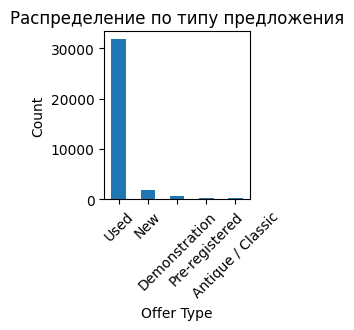

In [43]:
plt.subplot(2, 3, 6)
df['offer_type'].value_counts().plot(kind='bar')
plt.title('Распределение по типу предложения')
plt.xlabel('Offer Type')
plt.ylabel('Count')
plt.xticks(rotation=45)

Text(0, 0.5, 'Price')

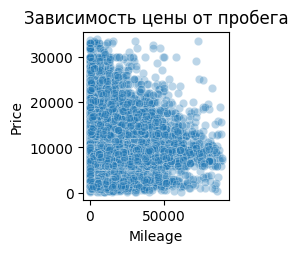

In [44]:
plt.subplot(2, 3, 4)
sns.scatterplot(data=cleaned_df, x='mileage', y='price', alpha=0.3)
plt.title('Зависимость цены от пробега')
plt.xlabel('Mileage')
plt.ylabel('Price')

In [ ]:
X = cleaned_df.drop('price', axis=1)
y = cleaned_df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

Размер обучающей выборки: (8104, 7)
Размер тестовой выборки: (2026, 7)


In [ ]:
numerical_features = ['mileage', 'power', 'age']
categorical_features = ['fuel', 'gear', 'offer_type', 'make_model']

numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Размер признаков после предобработки: {X_train_processed.shape}")

Размер признаков после предобработки: (8104, 1266)


In [ ]:
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', xgb.XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1,
                                    random_state=42, n_jobs=-1))
])

print("Обучение XGBoost...")
xgb_pipeline.fit(X_train, y_train)

y_pred_xgb = xgb_pipeline.predict(X_test)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"\n--- Результаты XGBoost ---")
print(f"MAE: {mae_xgb:.2f}")
print(f"RMSE: {rmse_xgb:.2f}")
print(f"R2: {r2_xgb:.4f}")

Обучение XGBoost...

--- Результаты XGBoost ---
MAE: 2230.60
RMSE: 3331.16
R2: 0.7099


Обучение нейронной сети...
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 819us/step

--- Результаты Нейронной сети ---
MAE: 1986.98
RMSE: 3152.02
R2: 0.7402


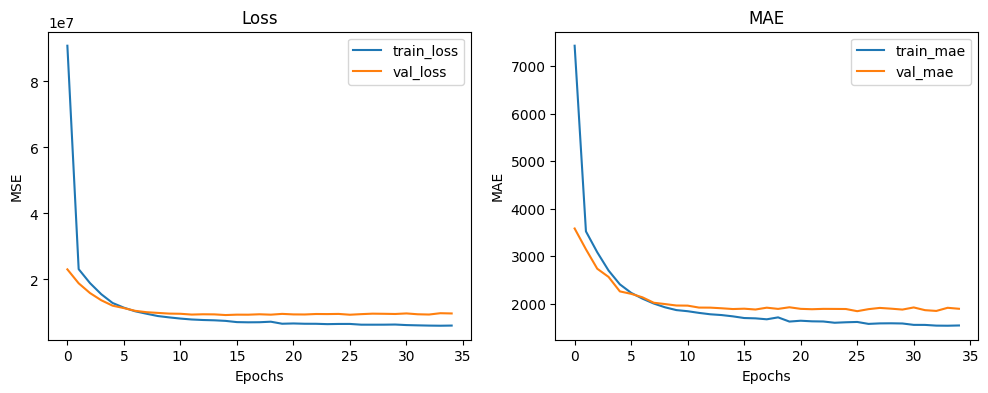

In [ ]:
X_train_nn = X_train_processed
X_test_nn = X_test_processed

model_nn = keras.Sequential([
    layers.Dense(256, activation='relu', input_shape=[X_train_nn.shape[1]]),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dense(1)
])

model_nn.compile(optimizer='adam',
                 loss='mse',
                 metrics=['mae'])

early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

print("Обучение нейронной сети...")
history = model_nn.fit(
    X_train_nn, y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)

y_pred_nn = model_nn.predict(X_test_nn).flatten()

mae_nn = mean_absolute_error(y_test, y_pred_nn)
rmse_nn = np.sqrt(mean_squared_error(y_test, y_pred_nn))
r2_nn = r2_score(y_test, y_pred_nn)

print(f"\n--- Результаты Нейронной сети ---")
print(f"MAE: {mae_nn:.2f}")
print(f"RMSE: {rmse_nn:.2f}")
print(f"R2: {r2_nn:.4f}")

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['mae'], label='train_mae')
plt.plot(history.history['val_mae'], label='val_mae')
plt.title('MAE')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.show()

In [37]:
print("\n" + "="*50)
print("СРАВНЕНИЕ МОДЕЛЕЙ")
print("="*50)

results = pd.DataFrame({
    'Model': ['XGBoost', 'Neural Network'],
    'MAE': [mae_xgb, mae_nn],
    'RMSE': [rmse_xgb, rmse_nn],
    'R2': [r2_xgb, r2_nn]
})

print(results.to_string(index=False))


СРАВНЕНИЕ МОДЕЛЕЙ
         Model         MAE        RMSE       R2
       XGBoost 2230.603271 3331.159258 0.709866
Neural Network 1986.980347 3152.017132 0.740232
